# Experiments — MLP From Scratch

## 1. Validation: XOR + Gradient Check

Before MNIST, we validate the network on the smallest non-linear problem (XOR)
and verify backpropagation by comparing the analytic gradient to a numeric one.

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))  # import the `mlp` package from the repo root

import numpy as np
import matplotlib.pyplot as plt

from mlp.network import MLP
from mlp.activations import softmax
from mlp.losses import cross_entropy
from mlp.optimizers import SGD, Adam

np.random.seed(0)

In [2]:
# XOR: output is 1 when the inputs differ. Not linearly separable ->
# only a network with hidden layer(s) can solve it.
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_labels = np.array([0, 1, 1, 0])

# One-hot (2 classes) to match softmax + cross-entropy.
y_xor = np.eye(2)[y_labels]
print("X:\n", X_xor)
print("y (one-hot):\n", y_xor)

X:
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
y (one-hot):
 [[1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]]


### Gradient check

The numeric gradient approximates `dL/dparam` from the definition of a derivative:
`(L(p + e) - L(p - e)) / (2e)`. If backprop is correct, analytic and numeric
gradients must match (difference < 1e-5).

In [3]:
def gradient_check(net, X, y, epsilon=1e-5):
    """Compare the analytic gradient (backprop) with the numeric one."""
    # Analytic gradient (what we want to validate).
    net.forward(X)
    grads_W, grads_b = net.backward(y)

    def loss_at():
        return cross_entropy(softmax(net.forward(X)), y)

    max_diff = 0.0
    # Check every weight, element by element.
    for layer in range(len(net.weights)):
        W = net.weights[layer]
        for idx in np.ndindex(W.shape):
            original = W[idx]

            W[idx] = original + epsilon
            loss_plus = loss_at()
            W[idx] = original - epsilon
            loss_minus = loss_at()
            W[idx] = original  # restore

            numeric = (loss_plus - loss_minus) / (2 * epsilon)
            analytic = grads_W[layer][idx]
            max_diff = max(max_diff, abs(numeric - analytic))

    return max_diff


net_check = MLP([2, 4, 2], activations=["relu"], seed=1)
diff = gradient_check(net_check, X_xor, y_xor)
print(f"Max analytic-vs-numeric difference: {diff:.2e}")
print("BACKPROP CORRECT!" if diff < 1e-5 else "SOMETHING IS WRONG in backward.")

Max analytic-vs-numeric difference: 6.39e-12
BACKPROP CORRECT!


Final loss: 0.0002745415543306413
Predictions: [0 1 1 0] | Expected: [0 1 1 0]


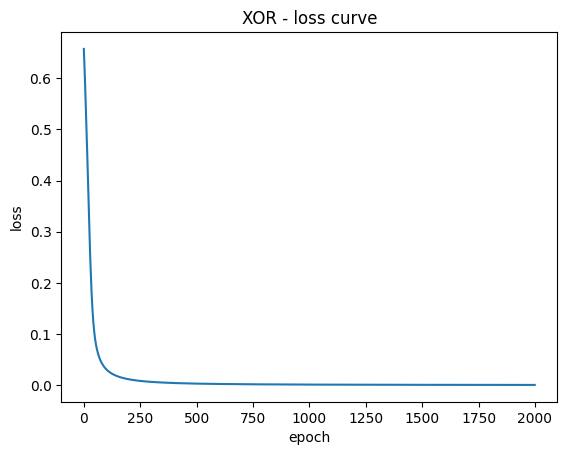

In [4]:
# Train on XOR to prove the network learns end-to-end.
net = MLP([2, 8, 8, 2], activations=["relu", "relu"], seed=42)
opt = Adam(lr=0.01)

losses = []
for epoch in range(2000):
    logits = net.forward(X_xor)
    loss = cross_entropy(softmax(logits), y_xor)
    losses.append(loss)

    grads_W, grads_b = net.backward(y_xor)
    opt.step(net.weights, net.biases, grads_W, grads_b)

print("Final loss:", losses[-1])
print("Predictions:", net.predict(X_xor), "| Expected:", y_labels)

plt.plot(losses)
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("XOR - loss curve")
plt.show()